# MobileNetV2 Genre Classifier
This notebook trains a MobileNetV2 model on GTZAN mel spectrograms.

In [1]:
!pip -q install librosa soundfile torchvision  kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.models as models

max_test_accuracy = -1
device = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR = os.path.join(path, "Data", "genres_original")

print("Using device:", device)
print("Using data dir:", DATA_DIR)

Using device: cuda
Using data dir: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original


In [4]:
N_FFT = 1024
HOP_LEN = 512

def generate_spectrogram(genre, file_name):
    file_path = os.path.join(DATA_DIR, genre, file_name)
    y, sr = librosa.load(file_path, sr=None)

    if len(y) < sr * 30:
        y = np.pad(y, (0, int(sr * 30) - len(y)))
    y = y[:int(sr * 30)]

    mel_spect = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN
    )
    mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
    mel_spect = (mel_spect - mel_spect.min()) / (mel_spect.max() - mel_spect.min())
    return mel_spect

In [5]:
def preprocess():
    x = []
    y = []
    skip_files = {"jazz.00054.wav"}  # known corrupted sample in GTZAN

    for genre_folder in os.scandir(DATA_DIR):
        genre = genre_folder.name
        for file_entry in os.scandir(genre_folder.path):
            sample = file_entry.name
            if sample in skip_files:
                continue
            spectrogram = generate_spectrogram(genre, sample)
            x.append(spectrogram)
            y.append(genre)

    mapping_encoder = LabelEncoder()
    y = mapping_encoder.fit_transform(y)
    mapping = dict(zip(range(len(mapping_encoder.classes_)), mapping_encoder.classes_))
    x = np.array(x)
    return x, y, mapping

x, y, mapping = preprocess()
print("Samples:", x.shape, y.shape)

Samples: (999, 128, 1292) (999,)


In [7]:
# Convert spectrograms to image tensors for MobileNetV2 [batch, 3, 224, 224]
x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
x_tensor = F.interpolate(x_tensor, size=(224, 224), mode="bilinear", align_corners=False)
x_tensor = x_tensor.repeat(1, 3, 1, 1)
y_tensor = torch.tensor(y, dtype=torch.long)

x_train, x_, y_train, y_ = train_test_split(
    x_tensor, y_tensor, test_size=0.15, random_state=90, stratify=y_tensor
)
x_val, x_test, y_val, y_test = train_test_split(
    x_, y_, test_size=0.33, random_state=90, stratify=y_
)

traindataset = TensorDataset(x_train, y_train)
valdataset = TensorDataset(x_val, y_val)
testdataset = TensorDataset(x_test, y_test)

trainloader = DataLoader(traindataset, batch_size=4, shuffle=True)
valloader = DataLoader(valdataset, batch_size=4, shuffle=False)
testloader = DataLoader(testdataset, batch_size=4, shuffle=False)

print("Tensor shape:", x_tensor.shape)
print("Train/Val/Test:", len(traindataset), len(valdataset), len(testdataset))

Tensor shape: torch.Size([999, 3, 224, 224])
Train/Val/Test: 849 100 50


In [8]:
class MobileNetV2Classifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.mobilenet_v2(weights=None)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [20]:
model = MobileNetV2Classifier(num_classes=len(mapping)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

validation_accuracies = []
training_loss = []
max_val_acc = -1
best_model_path = "mobilenetv2_genre.pth"

print("Starting MobileNetV2 training...")
epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in trainloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)
    training_loss.append(avg_train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in valloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    val_accuracy = 100 * correct / total
    validation_accuracies.append(val_accuracy)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_train_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    if val_accuracy > max_val_acc:
        max_val_acc = val_accuracy
        torch.save(model.state_dict(), best_model_path)
        print("Saved best MobileNetV2 at", val_accuracy)

Starting MobileNetV2 training...
Epoch [1/30] Loss: 2.2048 | Val Acc: 22.00%
Saved best MobileNetV2 at 22.0
Epoch [2/30] Loss: 2.0304 | Val Acc: 37.00%
Saved best MobileNetV2 at 37.0
Epoch [3/30] Loss: 1.8446 | Val Acc: 44.00%
Saved best MobileNetV2 at 44.0
Epoch [4/30] Loss: 1.7567 | Val Acc: 44.00%
Epoch [5/30] Loss: 1.6219 | Val Acc: 38.00%
Epoch [6/30] Loss: 1.5159 | Val Acc: 43.00%
Epoch [7/30] Loss: 1.4899 | Val Acc: 38.00%
Epoch [8/30] Loss: 1.4030 | Val Acc: 49.00%
Saved best MobileNetV2 at 49.0
Epoch [9/30] Loss: 1.3362 | Val Acc: 46.00%
Epoch [10/30] Loss: 1.3004 | Val Acc: 43.00%
Epoch [11/30] Loss: 1.2788 | Val Acc: 44.00%
Epoch [12/30] Loss: 1.1712 | Val Acc: 51.00%
Saved best MobileNetV2 at 51.0
Epoch [13/30] Loss: 1.1179 | Val Acc: 56.00%
Saved best MobileNetV2 at 56.0
Epoch [14/30] Loss: 1.0889 | Val Acc: 56.00%
Epoch [15/30] Loss: 0.9972 | Val Acc: 62.00%
Saved best MobileNetV2 at 62.0
Epoch [16/30] Loss: 0.9956 | Val Acc: 55.00%
Epoch [17/30] Loss: 0.9437 | Val Acc: 6

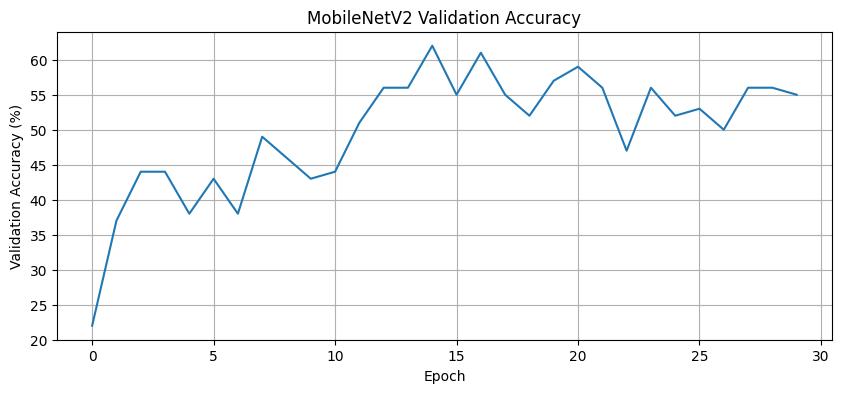

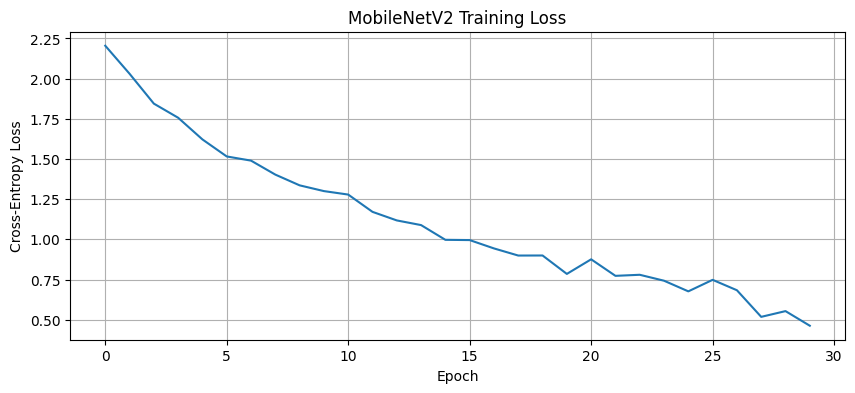

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(validation_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("MobileNetV2 Validation Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(training_loss)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MobileNetV2 Training Loss")
plt.grid(True)
plt.show()

In [22]:
best_model = MobileNetV2Classifier(num_classes=len(mapping)).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for x_batch, y_batch in testloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = best_model(x_batch)
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

test_accuracy = 100 * correct / total
print("MobileNetV2 Test Accuracy:", test_accuracy)

if test_accuracy > max_test_accuracy:
    max_test_accuracy = test_accuracy
    torch.save(best_model.state_dict(), "final_mobilenetv2_genre.pth")
    print("Saved final MobileNetV2 model")

MobileNetV2 Test Accuracy: 62.0
Saved final MobileNetV2 model


In [24]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.0 MB/s eta 0:00:00


## Export to ONNX
Export the trained MobileNetV2 checkpoint for mobile inference.

In [25]:
import warnings

onnx_path = "mobilenetv2_genre.onnx"

export_model = MobileNetV2Classifier(num_classes=len(mapping)).to(device)
export_model.load_state_dict(torch.load(best_model_path, map_location=device))
export_model.eval()

dummy_input = torch.randn(1, 3, 224, 224, device=device)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    torch.onnx.export(
        export_model,
        (dummy_input,),
        onnx_path,
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
        dynamo=False,
    )

print("Exported ONNX model:", onnx_path)

Exported ONNX model: mobilenetv2_genre.onnx
